#### 04/06/25
---
---
# <center> **Decision Tree**
---

## <center> **Projetos em Ciência de Dados**

#### <center> **Pós-Graduação - Instituto Mauá de Tecnologia**

#### <center> **VCP e Lucas Buk**
---
---


# **Algoritmos**

1.   ID3
2.   C45



# **Em linhas gerais:**

1. Selecione o atributo que melhor organiza a camada em análise.
2. Transforme esse atributo em um nó de decisão e divide o conjunto de dados em subconjuntos menores.
3. Serão criados nós filhos.
4. Inicia a construção da árvore repetindo este processo recursivamente para cada filho até que uma das condições corresponda:
    1.  Não há mais atributos restantes.
    2.  Não há mais instâncias.
    3.  Todos os dados pertencem ao mesmo atributo.


**Entropia**

$ \large H = -\sum_{n=1}^N p_n \log_2(p_n)$

**Ganho de organização**

$ \large G(X,atributo) = H(X) - H(X \vert \; \; atributo)$

# **Bibliotecas**

In [ ]:
# Bibliotecas básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Funções**

<ipython-input-5-d2fb3812e0d3>:4: RuntimeWarning: divide by zero encountered in log2
  H = -P * np.log2(P) - (1 - P) * np.log2((1 - P))  # Fórmula da entropia
<ipython-input-5-d2fb3812e0d3>:4: RuntimeWarning: invalid value encountered in multiply
  H = -P * np.log2(P) - (1 - P) * np.log2((1 - P))  # Fórmula da entropia


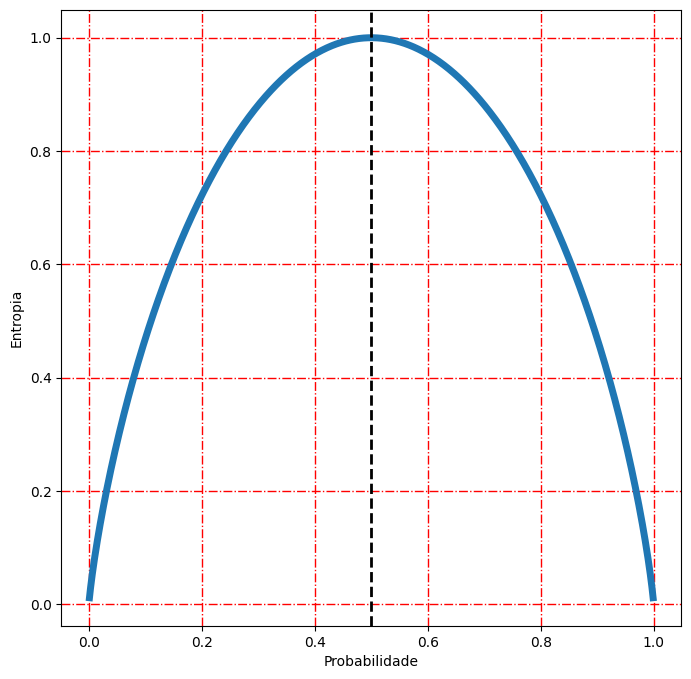

In [ ]:
def entropia(NE, NS):
    # Calcula a entropia dada o número de eventos NE e o número de amostras NS
    P = NE / NS  # Calcula a probabilidade de um evento
    H = -P * np.log2(P) - (1 - P) * np.log2((1 - P))  # Fórmula da entropia
    return H  # Retorna a entropia

# Geração de uma série de valores para NE (Número de Eventos) variando de 0 a 100
NE = np.linspace(0, 100, 1000)
NS = 100  # Número de Amostras constante

plt.figure(figsize=(8, 8))  # Define o tamanho da figura
plt.plot(NE / NS, entropia(NE, NS), lw=5)  # Plota a entropia em função da probabilidade NE/NS
plt.grid(color='r', linestyle='-.', linewidth=1)  # Adiciona uma grade ao gráfico
plt.axvline(x=0.5, color='k', linewidth=2.0, linestyle='--')  # Adiciona uma linha vertical em x=0.5
plt.xlabel('Probabilidade')  # Adiciona rótulo no eixo x
plt.ylabel('Entropia')  # Adiciona rótulo no eixo y

plt.show()  # Exibe o gráfico

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

def plot_cm(model, X, y, format='.3f'):
    """Função para exibir a matriz de confusão"""

    ConfusionMatrixDisplay.from_estimator(model, X, y,
                                          values_format=format,
                                          cmap='Blues',
                                          normalize='true')
    plt.show()

# **Planilha elementar para explicação de como a árvore decisão funciona**

In [ ]:
!gdown 1RpRmeZ1p5HhPoO75XA5KvtgwK-NtZm6O --quiet

In [ ]:
df = pd.read_csv('/content/ID3.csv')

print(df.shape)
df.head(3)

(14, 6)


,dia,panorama,temperatura,umidade,vento,decisao
0,1,Ensolarado,Quente,Alta,Fraco,Não
1,2,Ensolarado,Quente,Alta,Forte,Não
2,3,Nublado,Quente,Alta,Fraco,Sim


## **Entropia Global - primeira camada**

In [ ]:
N = df.shape[0]
N

14

In [ ]:
df[df.decisao == 'Sim'].shape[0]

9

In [ ]:
Freq_Sim = df[df.decisao == 'Sim'].shape[0]
Freq_Nao = df[df.decisao == 'Não'].shape[0]

Freq_Sim, Freq_Nao

(9, 5)

In [ ]:
P_Sim = Freq_Sim/N
P_Nao = Freq_Nao/N

P_Sim, P_Nao

(0.6428571428571429, 0.35714285714285715)

In [ ]:
Entropia = - P_Sim*np.log2(P_Sim) - P_Nao*np.log2(P_Nao)

Entropia

np.float64(0.9402859586706311)

## **Determinação do fator de decisão na primeira camada**

In [ ]:
df.head(3)

,dia,panorama,temperatura,umidade,vento,decisao
0,1,Ensolarado,Quente,Alta,Fraco,Não
1,2,Ensolarado,Quente,Alta,Forte,Não
2,3,Nublado,Quente,Alta,Fraco,Sim


### **Vento**

In [ ]:
df.vento.value_counts()

,count
vento,
Fraco,8
Forte,6


In [ ]:
N_fraco, N_forte = df.vento.value_counts()
N_fraco, N_forte

(8, 6)

In [ ]:
FiltroFraco = df['vento'] == 'Fraco'

data = df[FiltroFraco]
data

,dia,panorama,temperatura,umidade,vento,decisao
0,1,Ensolarado,Quente,Alta,Fraco,Não
2,3,Nublado,Quente,Alta,Fraco,Sim
3,4,Chuva,Ameno,Alta,Fraco,Sim
4,5,Chuva,Frio,Normal,Fraco,Sim
7,8,Ensolarado,Ameno,Alta,Fraco,Não
8,9,Ensolarado,Frio,Normal,Fraco,Sim
9,10,Chuva,Ameno,Normal,Fraco,Sim
12,13,Nublado,Quente,Normal,Fraco,Sim


In [ ]:
Freq_Sim = data[data.decisao == 'Sim'].shape[0]
Freq_Nao = data[data.decisao == 'Não'].shape[0]

Freq_Sim, Freq_Nao

(6, 2)

In [ ]:
P_Sim = Freq_Sim/N_fraco
P_Nao = Freq_Nao/N_fraco

P_Sim, P_Nao

(0.75, 0.25)

In [ ]:
EntropiaFraco = - P_Sim*np.log2(P_Sim) - P_Nao*np.log2(P_Nao)
P_fraco = N_fraco/N

EntropiaFraco, P_fraco

(np.float64(0.8112781244591328), 0.5714285714285714)

In [ ]:
import math

# Analisando o parâmetro Forte
FiltroForte = df['vento'] == 'Forte'

# Seleciona o dado somente com vento = 'Forte'
data = df[FiltroForte]

# Frequência de cada possibilidade de saída
Freq_Sim, Freq_Nao = data.decisao.value_counts()

# Probabilidades
P_Sim = Freq_Sim/N_forte
P_Nao = Freq_Nao/N_forte

# Entropia
EntropiaForte = - P_Sim * math.log(P_Sim, 2) - P_Nao * math.log(P_Nao, 2)

# Determinar a probabilidade da decisão quando vento é Forte
P_forte = N_forte/N

EntropiaForte, P_forte

(1.0, 0.42857142857142855)

In [ ]:
data.decisao.value_counts()

,count
decisao,
Não,3
Sim,3


In [ ]:
ganho_vento = Entropia - P_fraco*EntropiaFraco - P_forte*EntropiaForte

ganho_vento

np.float64(0.048127030408269544)

### **Panorama**

In [ ]:
# Categorias presentes na coluna panorama
df.panorama.value_counts()

,count
panorama,
Ensolarado,5
Chuva,5
Nublado,4


In [ ]:
# Salvando as frquências de cada categoria
N_ensol, N_chuva, N_nub = df.panorama.value_counts()
N_ensol, N_chuva, N_nub

(5, 5, 4)

In [ ]:
# Analisando o parâmetro Ensolarado
FiltroEnsol = df['panorama'] == 'Ensolarado'

# Seleciona o dado somente com panorama = 'Ensolarado'
data = df[FiltroEnsol]

# Frequência de cada possibilidade de saída
Freq_Sim, Freq_Nao = data.decisao.value_counts()

# Probabilidades
P_Sim = Freq_Sim/N_ensol
P_Nao = Freq_Nao/N_ensol

# Entropia
EntropiaEnsol = - P_Sim * math.log(P_Sim, 2) - P_Nao * math.log(P_Nao, 2)

# Determinar a probabilidade da decisão quando panorama é ensolarado
P_ensol = N_ensol/N

EntropiaEnsol, P_ensol

(0.9709505944546686, 0.35714285714285715)

In [ ]:
# Analisando o parâmetro Chuva
FiltroChuva = df['panorama'] == 'Chuva'

# Seleciona o dado somente com panorama = 'Chuva'
data = df[FiltroChuva]

# Frequência de cada possibilidade de saída
Freq_Sim, Freq_Nao = data.decisao.value_counts()

# Probabilidades
P_Sim = Freq_Sim/N_chuva
P_Nao = Freq_Nao/N_chuva

# Entropia
EntropiaChuva = - P_Sim * math.log(P_Sim, 2) - P_Nao * math.log(P_Nao, 2)

# Determinar a probabilidade da decisão quando panorama é chuva
P_chuva = N_chuva/N

EntropiaChuva, P_chuva

(0.9709505944546686, 0.35714285714285715)

In [ ]:
data.shape[0]

5

In [ ]:
# Analisando o parâmetro Nublado
FiltroNub = df['panorama'] == 'Nublado'

# Seleciona o dado somente com panorama = Nublado
data = df[FiltroNub]

# Frequência de cada possibilidade de saída
Freq_Sim = data.shape[0]
Freq_Nao = 0

# Probabilidades
P_Sim = Freq_Sim/N_nub
P_Nao = Freq_Nao/N_nub

# Determinamos a entropia
EntropiaNub = - P_Sim * math.log(P_Sim, 2) #- P_Nao * math.log(P_Nao, 2)

# Determinar a probabilidade da decisão quando panorama é Nublado
P_nub = N_nub/N

EntropiaNub, P_nub

(-0.0, 0.2857142857142857)

In [ ]:
# Analisando as ocorrências de panorama = Nublado
df.query('panorama == "Nublado"')

,dia,panorama,temperatura,umidade,vento,decisao
2,3,Nublado,Quente,Alta,Fraco,Sim
6,7,Nublado,Frio,Normal,Forte,Sim
11,12,Nublado,Ameno,Alta,Forte,Sim
12,13,Nublado,Quente,Normal,Fraco,Sim


In [ ]:
# Determinação do ganho da coluna panorama
ganho_panorama = Entropia - P_ensol*EntropiaEnsol - P_chuva*EntropiaChuva - P_nub*EntropiaNub

ganho_panorama

np.float64(0.24674981977443933)

**Conclusão:** a variável panorama permite uma organização melhor do que a variável vento.

## **Decision Tree**

In [ ]:
df.head(3)

,dia,panorama,temperatura,umidade,vento,decisao
0,1,Ensolarado,Quente,Alta,Fraco,Não
1,2,Ensolarado,Quente,Alta,Forte,Não
2,3,Nublado,Quente,Alta,Fraco,Sim


In [ ]:
# Encoder da coluna de saída
from sklearn.preprocessing import LabelEncoder

encoder_decisao = LabelEncoder()
df['decisao'] = encoder_decisao.fit_transform(df['decisao'])

df['decisao']

,decisao
0,0
1,0
2,1
3,1
4,1
5,0
6,1
7,0
8,1
9,1


In [ ]:
df.select_dtypes(include='object').columns

Index(['panorama', 'temperatura', 'umidade', 'vento'], dtype='object')

In [ ]:
feat_cols = df.select_dtypes(include='object').columns

le = dict()
for col in feat_cols:
    le[col] = LabelEncoder()
    df[col] = le[col].fit_transform(df[col])

le

{'panorama': LabelEncoder(),
 'temperatura': LabelEncoder(),
 'umidade': LabelEncoder(),
 'vento': LabelEncoder()}

In [ ]:
le['panorama'].classes_

array(['Chuva', 'Ensolarado', 'Nublado'], dtype=object)

In [ ]:
df

,dia,panorama,temperatura,umidade,vento,decisao
0,1,1,2,0,1,0
1,2,1,2,0,0,0
2,3,2,2,0,1,1
3,4,0,0,0,1,1
4,5,0,1,1,1,1
5,6,0,1,1,0,0
6,7,2,1,1,0,1
7,8,1,0,0,1,0
8,9,1,1,1,1,1
9,10,0,0,1,1,1


In [ ]:
feat_cols

Index(['panorama', 'temperatura', 'umidade', 'vento'], dtype='object')

In [ ]:
X = df[feat_cols].copy()

y = df.decisao.copy()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(criterion='entropy', random_state=25)
classifier.fit(X, y)

DecisionTreeClassifier(criterion='entropy', random_state=25)

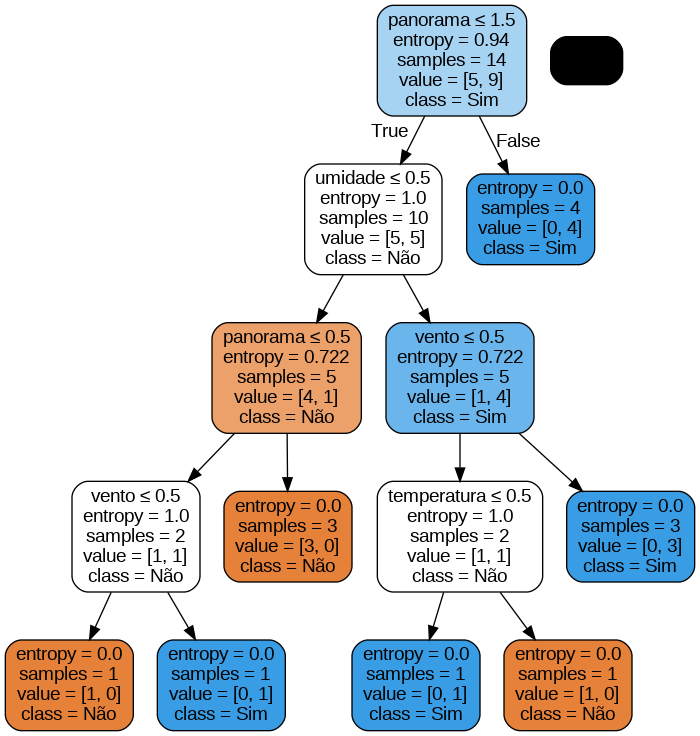

In [ ]:
# Plot da árvore de decisão
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
import pydotplus

dot_data = StringIO()
export_graphviz(classifier, out_file=dot_data, filled=True,
                rounded=True, special_characters=True,
                feature_names=feat_cols,
                class_names=['Não','Sim'])

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

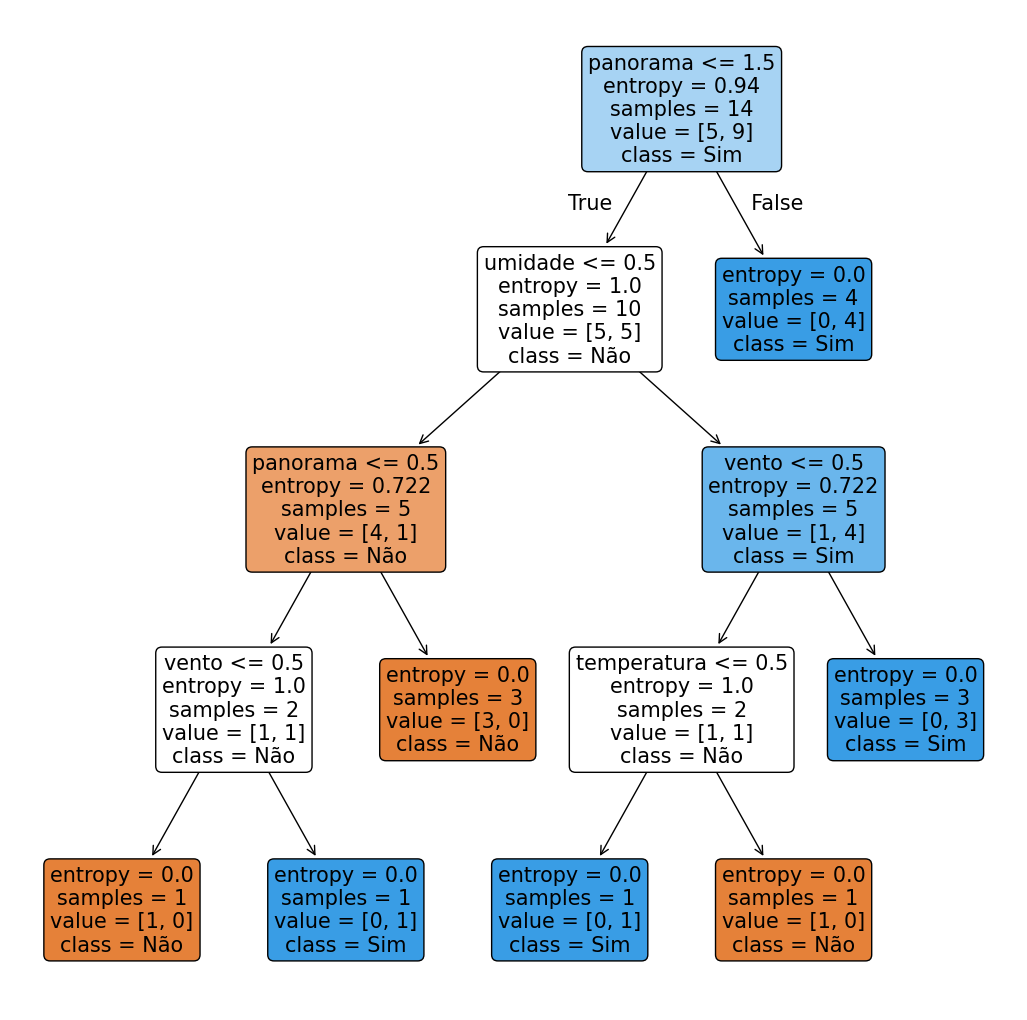

In [ ]:
# Outra forma de plotar a árvore de decisão
from sklearn import tree

plt.figure(figsize = (13, 13))
tree.plot_tree(classifier,
               feature_names=feat_cols,
               class_names=['Não', 'Sim'],
               filled=True,
               rounded=True)
plt.show()

# **Outro exemplo usando DecisionTreeClassifier**

In [ ]:
# Dataset - Social
!gdown 1PraM6t4lSJvHFbYb2dgsRMWIoR3K2wSl --quiet

In [ ]:
# Leitura dos dados
data = pd.read_csv('Social.csv')
print(data.shape)
data.head(3)

## **Preparação e Treinamento**

In [ ]:
# 3 exemplos do banco de dados
data.sample(3)

**Separação entre Features e Label**

**Separação entre conjunto de treino e teste**

**Normalização dos dados**

**Aprendizado**

### **Balancear**

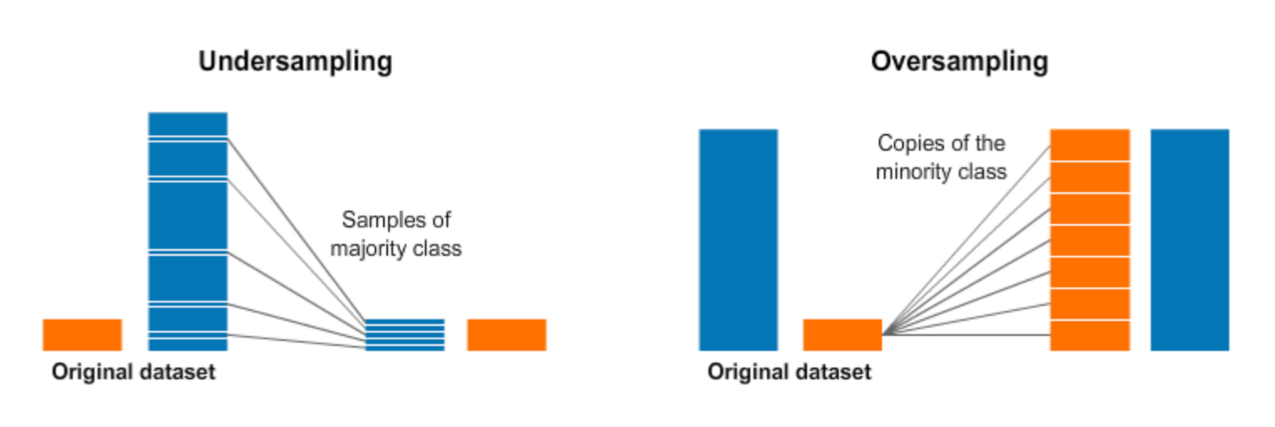

**Undersampling**

**Oversampling**


https://towardsdatascience.com/stop-using-smote-to-treat-class-imbalance-take-this-intuitive-approach-instead-9cb822b8dc45

### **Pesos das classes**

**compute_class_weight:** https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html

**Avaliação: predição e métricas**

**Visualização da fronteira de decisão do modelo**

In [ ]:
from matplotlib.colors import ListedColormap

plt.figure(figsize = (10, 6))

# Define os conjuntos de teste normalizados para X e y
X_set, y_set = X_test_norm, y_test

# Criação de uma grade de valores para as duas features (Age e Estimated Salary)
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min() - 0.25,
                               stop=X_set[:, 0].max() + 0.25, step=0.01),
                     np.arange(start=X_set[:, 1].min() - 0.25,
                               stop=X_set[:, 1].max() + 0.25, step=0.01))

# Previsão da classe para cada ponto na grade e criação do gráfico de contorno
plt.contourf(X1, X2, dt.predict(np.array([X1.ravel(),
                                          X2.ravel()]).T).reshape(X1.shape),
             alpha=0.75, cmap=ListedColormap(('cyan', 'yellow')))

# Define os limites do gráfico
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Plota os pontos de teste, colorindo cada classe diferente
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set==j, 0],
                X_set[y_set==j, 1],
                color=ListedColormap(('red','green'))(i), label=j)

# Adiciona título e rótulos aos eixos
plt.title('DecisionTree (Conjunto de dados de teste)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

In [ ]:
# Visualisação de uma parte da árvore
plt.figure(figsize = (20, 10))
tree.plot_tree(dt, feature_names=feature_cols,
               class_names=['0', '1'],
               filled=True, rounded=True,
               max_depth=3);

# **T1**

**Crie um modelo Decision Tree para classificar a qualidade dos vinhos e exiba a árvore gerada.**

**Dados:** https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

Input variables (based on physicochemical tests):

* fixed acidity

* volatile acidity

* citric acid

* residual sugar

* chlorides

* free sulfur dioxide

* total sulfur dioxide

* density

* pH

* sulphates

* alcohol

Output variable (based on sensory data):

* quality (score between 0 and 10)

In [ ]:
# Download do conjunto de dados
!gdown 1ttOCd6VQH85CfdRvGXqt4UI3pjF73vJl --quiet

Sugestões de etapas:


1.   Ler os dados
2.   Criação do Label (1 se maior que 5, 0 caso contrário)
3.   Análise do dataset (Valores faltantes, pairplot, matriz de correlação, ...)
4.   Divisão dos dados em treino e teste
5.   Pré-processamento
6.   Treinamento do modelo DecisionTree
7.   Validação do modelo e exibição de uma parte da árvore



# **Referências**

**Árvore de decisão:** https://didatica.tech/como-funciona-o-algoritmo-arvore-de-decisao/

**Aprendizado de máquina: Árvore de Decisão Indutiva:** https://www.cin.ufpe.br/~pacm/SI/ArvoreDecisaoIndutiva.pdf

**DecisionTree scikit-learn:** https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

**Comparação diferentes normalizadores:** https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html#sphx-glr-auto-examples-preprocessing-plot-all-scaling-py